In [1]:
import sys

print(sys.executable)

d:\JamTerbang\DL\KlasifikasiEkspresi\.venv\Scripts\python.exe


In [3]:
import os

train_dir = "../dataset/train"
test_dir = "../dataset/test"

print("Isi folder train:")
print(os.listdir(train_dir))

print("\nIsi folder test:")
print(os.listdir(test_dir))

Isi folder train:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Isi folder test:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [4]:
for emotion in os.listdir(train_dir):
    path = os.path.join(train_dir, emotion)
    jumlah = len (os.listdir(path))
    print(emotion, " : ", jumlah)

angry  :  3995
disgust  :  436
fear  :  4097
happy  :  7215
neutral  :  4965
sad  :  4830
surprise  :  3171


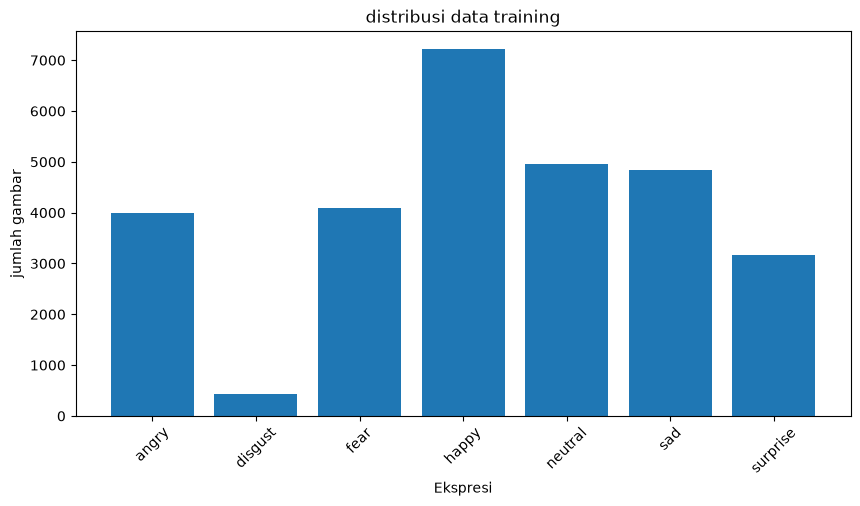

In [7]:
import matplotlib.pyplot as plt

emotions = []
counts = []

for emotion in os.listdir(train_dir):
    path = os.path.join(train_dir, emotion)
    jumlah = len(os.listdir(path))
    
    emotions.append(emotion)
    counts.append(jumlah)

plt.figure(figsize=(10,5))
plt.bar(emotions,counts)
plt.title("distribusi data training")
plt.xlabel("Ekspresi")
plt.ylabel("jumlah gambar")
plt.xticks(rotation=45)
plt.show()

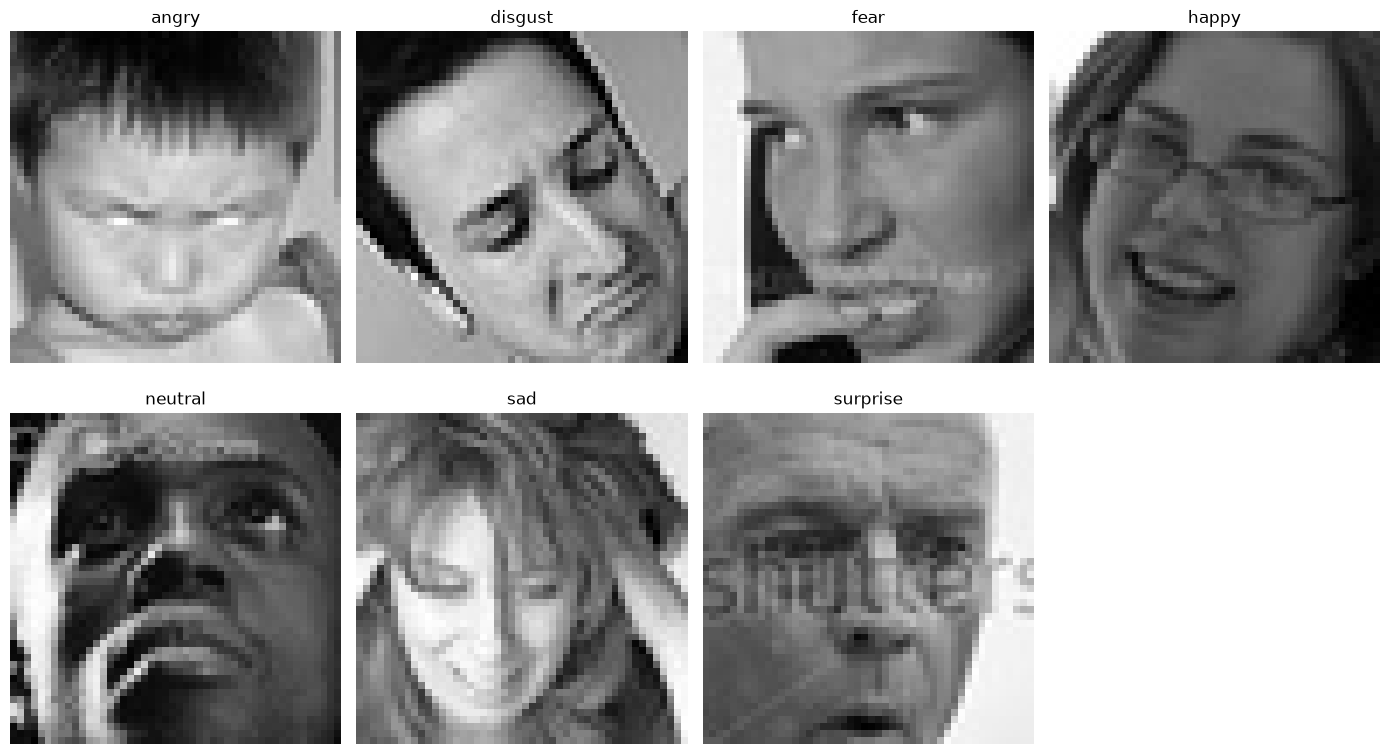

In [11]:
from PIL import Image


emotions = sorted(os.listdir(train_dir))

plt.figure(figsize=(14, 8))

for i, emotion in enumerate(emotions):
    folder = os.path.join(train_dir, emotion)
    image_name = os.listdir(folder)[0]
    image_path = os.path.join(folder, image_name)

    image = Image.open(image_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(emotion)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Ambil satu gambar dari folder happy
happy_folder = os.path.join(train_dir, "happy")
image_name = os.listdir(happy_folder)[0]
image_path = os.path.join(happy_folder, image_name)

image = Image.open(image_path)

print("Nama file :", image_name)
print("Ukuran    :", image.size)
print("Mode      :", image.mode)


Nama file : Training_10019449.jpg
Ukuran    : (48, 48)
Mode      : L


In [ ]:
def check_images(folder):
    total = 0
    invalid = 0
    wrong_size = 0

    for emotion in os.listdir(folder):
        emotion_path = os.path.join(folder, emotion)

        for image_name in os.listdir(emotion_path):
            image_path = os.path.join(emotion_path, image_name)
            total += 1

            try:
                image = Image.open(image_path)

                if image.size != (48, 48):
                    wrong_size += 1

            except:
                invalid += 1

    print("Total gambar :", total)
    print("Gambar rusak:", invalid)
    print("Ukuran salah:", wrong_size)


print("TRAIN")
check_images(train_dir)

print("\nTEST")
check_images(test_dir)

TRAIN
Total gambar : 28709
Gambar rusak: 0
Ukuran salah: 0

TEST
Total gambar : 7178
Gambar rusak: 0
Ukuran salah: 0


In [14]:
test_count = {}

for emotion in os.listdir(test_dir):
    path = os.path.join(test_dir, emotion)
    test_count[emotion] = len(os.listdir(path))

print("distribusi data test: ")

for emotion, jumlah in test_count.items():
    print(f"{emotion:10} : {jumlah}")

distribusi data test: 
angry      : 958
disgust    : 111
fear       : 1024
happy      : 1774
neutral    : 1233
sad        : 1247
surprise   : 831


In [16]:
import os
import hashlib


def get_image_hash(image_path):
    with open(image_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


def get_all_hashes(folder):
    hashes = set()

    for emotion in os.listdir(folder):
        emotion_path = os.path.join(folder, emotion)

        for image_name in os.listdir(emotion_path):
            image_path = os.path.join(emotion_path, image_name)

            file_hash = get_image_hash(image_path)
            hashes.add(file_hash)

    return hashes


train_hashes = get_all_hashes(train_dir)
test_hashes = get_all_hashes(test_dir)

duplicates = train_hashes.intersection(test_hashes)

print("Jumlah gambar train :", len(train_hashes))
print("Jumlah gambar test  :", len(test_hashes))
print("Duplikasi           :", len(duplicates))

Jumlah gambar train : 27473
Jumlah gambar test  : 7092
Duplikasi           : 531


In [17]:
from collections import defaultdict


def get_hash_info(folder):
    hash_info = defaultdict(list)

    for emotion in os.listdir(folder):
        emotion_path = os.path.join(folder, emotion)

        for image_name in os.listdir(emotion_path):
            image_path = os.path.join(emotion_path, image_name)

            with open(image_path, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            hash_info[file_hash].append({
                "emotion": emotion,
                "filename": image_name
            })

    return hash_info


train_info = get_hash_info(train_dir)
test_info = get_hash_info(test_dir)

duplicate_hashes = set(train_info.keys()).intersection(test_info.keys())

print("Jumlah hash yang muncul di train dan test:", len(duplicate_hashes))

same_label = 0
different_label = 0

for file_hash in duplicate_hashes:
    train_labels = set(item["emotion"] for item in train_info[file_hash])
    test_labels = set(item["emotion"] for item in test_info[file_hash])

    if train_labels.intersection(test_labels):
        same_label += 1
    else:
        different_label += 1

print("Duplikasi dengan label sama   :", same_label)
print("Duplikasi dengan label berbeda:", different_label)

Jumlah hash yang muncul di train dan test: 531
Duplikasi dengan label sama   : 516
Duplikasi dengan label berbeda: 15


In [18]:
conflicting_hashes = []

for file_hash in duplicate_hashes:
    train_labels = set(item["emotion"] for item in train_info[file_hash])
    test_labels = set(item["emotion"] for item in test_info[file_hash])

    if train_labels.isdisjoint(test_labels):
        conflicting_hashes.append(file_hash)

print("Jumlah konflik:", len(conflicting_hashes))

for i, file_hash in enumerate(conflicting_hashes, start=1):
    print(f"\nKonflik {i}")
    print("Hash:", file_hash)

    print("Train:")
    for item in train_info[file_hash]:
        print(" ", item["emotion"], "-", item["filename"])

    print("Test:")
    for item in test_info[file_hash]:
        print(" ", item["emotion"], "-", item["filename"])

Jumlah konflik: 15

Konflik 1
Hash: 62967ac50bceb462e39871f44bbb0261
Train:
  surprise - Training_9419936.jpg
Test:
  fear - PublicTest_78036016.jpg

Konflik 2
Hash: c43f65a6fda93f0f353a7225a43c119f
Train:
  fear - Training_49712780.jpg
Test:
  surprise - PublicTest_75474602.jpg

Konflik 3
Hash: 39b8cd10a7a876e399a9cf451b5a056f
Train:
  fear - Training_54883964.jpg
Test:
  angry - PrivateTest_1850005.jpg

Konflik 4
Hash: 325952e5f7c72c0d6a291833271bcaa3
Train:
  fear - Training_74428465.jpg
Test:
  angry - PrivateTest_99012891.jpg

Konflik 5
Hash: a8212a72b8b38052d5f2cf3ea236a427
Train:
  neutral - Training_64154751.jpg
Test:
  sad - PublicTest_376099.jpg

Konflik 6
Hash: 5d4f089e25473c98d442f27d32512cd1
Train:
  angry - Training_92166104.jpg
Test:
  disgust - PublicTest_75786377.jpg

Konflik 7
Hash: 5aeaf01372e03741b1f46e30cd51c5a2
Train:
  sad - Training_61977451.jpg
  sad - Training_79860018.jpg
Test:
  angry - PrivateTest_24760870.jpg

Konflik 8
Hash: abf50698223c25e520b3c369e8f518

In [19]:
overlap_test_files = []

for file_hash in duplicate_hashes:
    train_labels = set(item["emotion"] for item in train_info[file_hash])

    for item in test_info[file_hash]:
        overlap_test_files.append({
            "hash": file_hash,
            "test_emotion": item["emotion"],
            "test_filename": item["filename"],
            "train_labels": ", ".join(sorted(train_labels))
        })

print("Jumlah file test yang overlap dengan train:",
      len(overlap_test_files))

Jumlah file test yang overlap dengan train: 568


In [20]:
import pandas as pd

overlap_df = pd.DataFrame(overlap_test_files)

print(overlap_df.head())
print("\nTotal file:", len(overlap_df))

                               hash test_emotion             test_filename  \
0  e0c1b89e0267b8b336cd4308636b60e0          sad   PublicTest_20224413.jpg   
1  ea2cfd76091473fa6dda82f382493abe        happy    PublicTest_6945961.jpg   
2  62967ac50bceb462e39871f44bbb0261         fear   PublicTest_78036016.jpg   
3  1e0b1ca363136be026dca29cb3cf2ddd     surprise   PublicTest_61779535.jpg   
4  18272724756c54fccbbc9b10e920790e      disgust  PrivateTest_46114477.jpg   

  train_labels  
0          sad  
1        happy  
2     surprise  
3     surprise  
4      disgust  

Total file: 568


In [21]:
import os
import shutil

clean_test_dir = "../dataset/fer2013_clean/test"

# Buat folder test clean
os.makedirs(clean_test_dir, exist_ok=True)

removed_count = 0
copied_count = 0

for emotion in os.listdir(test_dir):
    source_emotion_dir = os.path.join(test_dir, emotion)
    target_emotion_dir = os.path.join(clean_test_dir, emotion)

    os.makedirs(target_emotion_dir, exist_ok=True)

    for image_name in os.listdir(source_emotion_dir):
        source_path = os.path.join(source_emotion_dir, image_name)

        # Hitung hash file test
        file_hash = get_image_hash(source_path)

        # Jika file juga ada di train, jangan disalin
        if file_hash in train_hashes:
            removed_count += 1
            continue

        target_path = os.path.join(target_emotion_dir, image_name)

        shutil.copy2(source_path, target_path)
        copied_count += 1

print("File yang tidak disalin karena overlap :", removed_count)
print("File yang disalin ke test clean       :", copied_count)

File yang tidak disalin karena overlap : 568
File yang disalin ke test clean       : 6610


In [22]:
clean_hashes = get_all_hashes(clean_test_dir)

remaining_overlap = train_hashes.intersection(clean_hashes)

print("Jumlah gambar test clean :", len(clean_hashes))
print("Overlap dengan train     :", len(remaining_overlap))

Jumlah gambar test clean : 6561
Overlap dengan train     : 0


In [23]:
for emotion in sorted(os.listdir(clean_test_dir)):
    emotion_path = os.path.join(clean_test_dir, emotion)
    jumlah = len(os.listdir(emotion_path))
    print(f"{emotion:10} : {jumlah}")

print("\nTotal file test clean :", 
      sum(len(os.listdir(os.path.join(clean_test_dir, emotion)))
          for emotion in os.listdir(clean_test_dir)))

angry      : 892
disgust    : 80
fear       : 930
happy      : 1717
neutral    : 1189
sad        : 1203
surprise   : 599

Total file test clean : 6610


In [24]:
train_duplicate_hashes = []

for file_hash, items in train_info.items():
    if len(items) > 1:
        train_duplicate_hashes.append(file_hash)

print("Jumlah hash yang muncul lebih dari sekali di train:",
      len(train_duplicate_hashes))

print("Jumlah file yang terkait duplicate internal:",
      sum(len(train_info[h]) for h in train_duplicate_hashes))

Jumlah hash yang muncul lebih dari sekali di train: 1035
Jumlah file yang terkait duplicate internal: 2271


In [25]:
clean_test_info = get_hash_info(clean_test_dir)

clean_test_duplicate_hashes = []

for file_hash, items in clean_test_info.items():
    if len(items) > 1:
        clean_test_duplicate_hashes.append(file_hash)

print("Jumlah hash duplicate di test clean:",
      len(clean_test_duplicate_hashes))

print("Jumlah file yang terkait duplicate:",
      sum(len(clean_test_info[h]) for h in clean_test_duplicate_hashes))

Jumlah hash duplicate di test clean: 49
Jumlah file yang terkait duplicate: 98


In [26]:
same_label_train = 0
different_label_train = 0

for file_hash, items in train_info.items():
    if len(items) > 1:
        labels = set(item["emotion"] for item in items)

        if len(labels) == 1:
            same_label_train += 1
        else:
            different_label_train += 1

print("Duplicate train dengan label sama   :", same_label_train)
print("Duplicate train dengan label berbeda:", different_label_train)

Duplicate train dengan label sama   : 996
Duplicate train dengan label berbeda: 39


In [27]:
same_label_test = 0
different_label_test = 0

for file_hash, items in clean_test_info.items():
    if len(items) > 1:
        labels = set(item["emotion"] for item in items)

        if len(labels) == 1:
            same_label_test += 1
        else:
            different_label_test += 1

print("Duplicate test dengan label sama   :", same_label_test)
print("Duplicate test dengan label berbeda:", different_label_test)

Duplicate test dengan label sama   : 47
Duplicate test dengan label berbeda: 2


In [28]:
# Konflik label di TRAIN
conflicting_train_hashes = []

for file_hash, items in train_info.items():
    labels = set(item["emotion"] for item in items)

    if len(labels) > 1:
        conflicting_train_hashes.append(file_hash)


# Konflik label di TEST CLEAN
conflicting_test_hashes = []

for file_hash, items in clean_test_info.items():
    labels = set(item["emotion"] for item in items)

    if len(labels) > 1:
        conflicting_test_hashes.append(file_hash)


train_conflict_files = sum(
    len(train_info[file_hash])
    for file_hash in conflicting_train_hashes
)

test_conflict_files = sum(
    len(clean_test_info[file_hash])
    for file_hash in conflicting_test_hashes
)


print("TRAIN")
print("Jumlah hash konflik :", len(conflicting_train_hashes))
print("Jumlah file konflik :", train_conflict_files)

print("\nTEST CLEAN")
print("Jumlah hash konflik :", len(conflicting_test_hashes))
print("Jumlah file konflik :", test_conflict_files)

TRAIN
Jumlah hash konflik : 39
Jumlah file konflik : 107

TEST CLEAN
Jumlah hash konflik : 2
Jumlah file konflik : 4


In [35]:
print("===== RINGKASAN EDA FER-2013 =====")

print("\n1. JUMLAH DATA AWAL")
print("Train :", 28709)
print("Test  :", 7178)

print("\n2. INFORMASI GAMBAR")
print("Ukuran  : 48 x 48 pixel")
print("Mode    : Grayscale")

print("\n3. DISTRIBUSI KELAS TRAIN")
for emotion in sorted(os.listdir(train_dir)):
    path = os.path.join(train_dir, emotion)
    print(f"{emotion:10} : {len(os.listdir(path))}")

print("\n4. DISTRIBUSI KELAS TEST CLEAN")
for emotion in sorted(os.listdir(clean_test_dir)):
    path = os.path.join(clean_test_dir, emotion)
    print(f"{emotion:10} : {len(os.listdir(path))}")

print("\n5. DATA LEAKAGE")
print("Hash overlap train-test :", 531)
print("File test overlap      :", 568)

print("\n6. KONFLIK LABEL")
print("Train :", 39, "hash / 107 file")
print("Test  :", 2, "hash / 4 file")

print("\n7. DATASET HASIL CLEANING")
print("Train clean :", 27434)
print("Test clean  :", 6559)

===== RINGKASAN EDA FER-2013 =====

1. JUMLAH DATA AWAL
Train : 28709
Test  : 7178

2. INFORMASI GAMBAR
Ukuran  : 48 x 48 pixel
Mode    : Grayscale

3. DISTRIBUSI KELAS TRAIN
angry      : 3995
disgust    : 436
fear       : 4097
happy      : 7215
neutral    : 4965
sad        : 4830
surprise   : 3171

4. DISTRIBUSI KELAS TEST CLEAN
angry      : 892
disgust    : 80
fear       : 930
happy      : 1717
neutral    : 1189
sad        : 1203
surprise   : 599

5. DATA LEAKAGE
Hash overlap train-test : 531
File test overlap      : 568

6. KONFLIK LABEL
Train : 39 hash / 107 file
Test  : 2 hash / 4 file

7. DATASET HASIL CLEANING
Train clean : 27434
Test clean  : 6559


# Kesimpulan EDA

Dataset FER-2013 yang digunakan terdiri dari 28.709 gambar training dan 7.178 gambar testing. Seluruh gambar memiliki ukuran 48×48 pixel dan menggunakan grayscale.

Hasil pemeriksaan menunjukkan adanya exact duplicate antara training dan testing. Ditemukan 568 file test yang memiliki konten identik dengan data training, sehingga file tersebut dikeluarkan dari test set untuk mengurangi risiko data leakage.

Selain itu, ditemukan duplicate internal yang memiliki konflik label. Terdapat 39 kelompok konflik pada training yang melibatkan 107 file dan 2 kelompok konflik pada test clean yang melibatkan 4 file. Data konflik tersebut tidak digunakan dalam dataset hasil cleaning.

Dataset hasil cleaning terdiri dari 27.434 gambar training dan 6.559 gambar testing. Dataset ini selanjutnya akan digunakan pada tahap preprocessing dan pembagian training-validation.